f# Qadence Kickstart: Graph Kernels, Generalization & Barren Plateaus

**Lessons 04 + 05 of the QML study guide.**

This notebook closes the *kernel* arc and opens the *trainability* arc — the two ideas that decide whether a
quantum model is worth running:

1. **Graph data & the Weisfeiler–Lehman kernel** — graphs are QEK's native input; WL is the classical baseline
   the **Quantum Evolution Kernel (QEK)** must beat.
2. **Permutation invariance** — why comparing graphs is subtle, and the symmetry that motivates equivariant models.
3. **Generalization** — overfitting, regularization, and honest model selection by cross-validation.
4. **Barren plateaus** — gradients that vanish as a model grows, the central QML trainability wall.
5. **One trade-off, two faces** — barren plateaus and kernel concentration are formally the *same* phenomenon
   (`arXiv:2501.07433`); we show them collapsing side by side.

> **Prereqs:** Lessons 02–03 (Gram matrices, `SVC(kernel="precomputed")`). The downstream learner here is
> *byte-for-byte* the Lesson 03 SVM — only the kernel changes from RBF-on-vectors to WL-on-graphs.


## Setup

One import block reused throughout. Run this first.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch.nn as nn
from collections import Counter
from sklearn.svm import SVC

torch.manual_seed(20000)
print("setup ready")

setup ready


---
# Lesson 04 — Graph Data & Graph Kernels

## 1. Representing a graph

A graph is **nodes + edges**. In tensors: an **adjacency matrix** `A` (who connects to whom) and, optionally,
**node labels** (e.g. the chemical element of each atom). Molecules are the canonical case — atoms are nodes,
bonds are edges — and exactly the data behind Pasqal's toxicity-prediction work.

We draw the graph next to its adjacency matrix so the correspondence is concrete.

degrees (row sums): [1.0, 2.0, 2.0, 1.0]   (ends have 1 neighbour, middle nodes 2)
symmetric (undirected): True


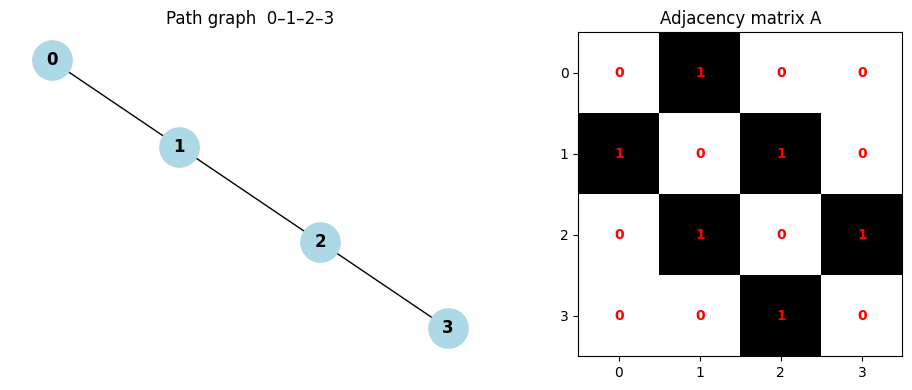

In [2]:
# a 4-node "path" graph: 0–1–2–3
A_path = torch.tensor([
    [0, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [0, 0, 1, 0],
], dtype=torch.float)

print("degrees (row sums):", A_path.sum(1).tolist(), "  (ends have 1 neighbour, middle nodes 2)")
print("symmetric (undirected):", torch.allclose(A_path, A_path.T))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
G = nx.from_numpy_array(A_path.numpy())
nx.draw(G, nx.spring_layout(G, seed=1), with_labels=True, node_color='lightblue',
        node_size=800, font_weight='bold', ax=ax1)
ax1.set_title('Path graph  0–1–2–3')

ax2.imshow(A_path, cmap='Greys', vmin=0, vmax=1)
ax2.set_title('Adjacency matrix A'); ax2.set_xticks(range(4)); ax2.set_yticks(range(4))
for i in range(4):
    for j in range(4):
        ax2.text(j, i, int(A_path[i, j]), ha='center', va='center',
                 color='red', fontweight='bold')
plt.tight_layout(); plt.show()

## 2. Why comparing graphs is hard: permutation invariance

The *same* graph can be written with its nodes listed in any order — there's no canonical numbering. Relabel
the nodes and the adjacency matrix changes entirely, even though the graph is identical. A good graph similarity
must therefore be **permutation invariant**: relabeling nodes must not change the answer.

A naive `A == A'` comparison fails this test. This is the same symmetry concern that motivates *equivariant*
models in Lesson 10.

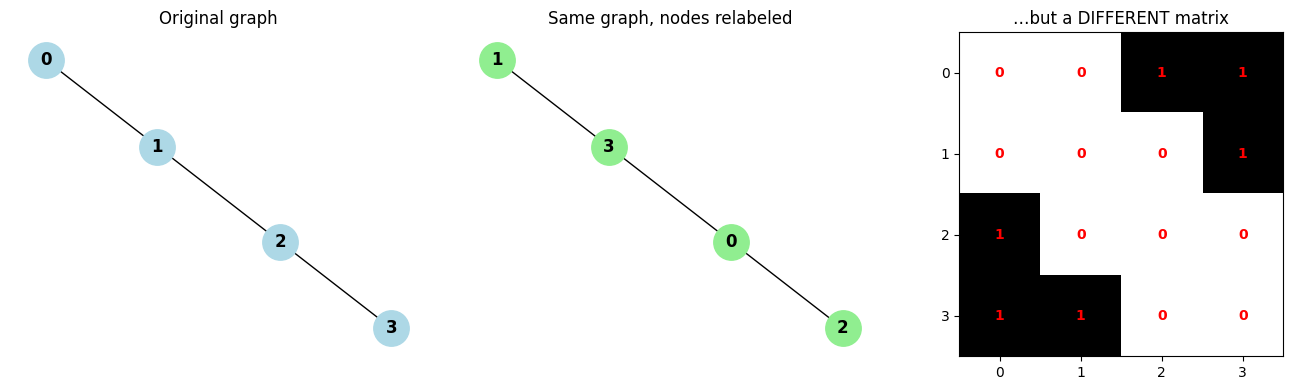

graphs isomorphic (truly the same): True
naive A == A_perm                  : False  <- matrix comparison is fooled


In [3]:
# relabel the nodes by a permutation: the GRAPH is unchanged, the MATRIX is not
perm = torch.tensor([2, 0, 3, 1])
P = torch.eye(4)[perm]
A_perm = P @ A_path @ P.T

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
G0 = nx.from_numpy_array(A_path.numpy())
G1 = nx.from_numpy_array(A_perm.numpy())
nx.draw(G0, nx.spring_layout(G0, seed=1), with_labels=True, node_color='lightblue',
        node_size=650, font_weight='bold', ax=axes[0]); axes[0].set_title('Original graph')
nx.draw(G1, nx.spring_layout(G1, seed=1), with_labels=True, node_color='lightgreen',
        node_size=650, font_weight='bold', ax=axes[1]); axes[1].set_title('Same graph, nodes relabeled')
axes[2].imshow(A_perm, cmap='Greys', vmin=0, vmax=1); axes[2].set_title('…but a DIFFERENT matrix')
axes[2].set_xticks(range(4)); axes[2].set_yticks(range(4))
for i in range(4):
    for j in range(4):
        axes[2].text(j, i, int(A_perm[i, j]), ha='center', va='center', color='red', fontweight='bold')
plt.tight_layout(); plt.show()

print("graphs isomorphic (truly the same):", nx.is_isomorphic(G0, G1))
print("naive A == A_perm                  :", torch.allclose(A_path, A_perm), " <- matrix comparison is fooled")

## 3. The Weisfeiler–Lehman (WL) kernel

WL is the standard strong, cheap, permutation-invariant baseline. The intuition is **iterative label
refinement**: each round, replace every node's label by a hash of *its own label + its sorted neighbours'
labels*. After a few rounds, two graphs are similar if they share many such refined labels. The kernel is the
**inner product of label-count histograms** — note the echo of Lesson 02: a kernel is a feature map (here, the
histogram) followed by an inner product.

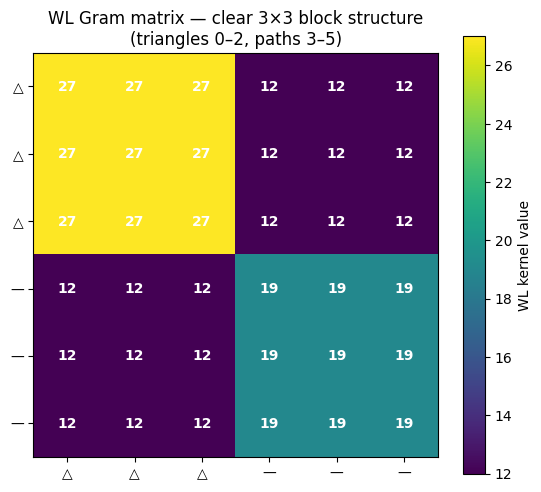

same-class graphs score higher (27 / 19) than cross-class (12) -> a learnable signal


In [4]:
def wl_histograms(A, node_labels, n_iter=2):
    """Counter of all WL labels seen across iterations for one graph."""
    labels = list(node_labels)
    hist = Counter(labels)
    n = A.shape[0]
    neighbors = [torch.nonzero(A[i]).flatten().tolist() for i in range(n)]
    for _ in range(n_iter):
        new = []
        for i in range(n):
            neigh = sorted(labels[j] for j in neighbors[i])          # sorted -> permutation invariant
            new.append(f"{labels[i]}|{','.join(map(str, neigh))}")   # own label + neighbour labels
        labels = new
        hist.update(labels)
    return hist

def wl_kernel(g1, g2, n_iter=2):
    h1 = wl_histograms(*g1, n_iter)
    h2 = wl_histograms(*g2, n_iter)
    return sum(h1[k] * h2[k] for k in set(h1) | set(h2))             # histogram inner product

# tiny dataset: three triangles (class 0) and three 3-paths (class 1), all carbon "C"
def triangle():
    return (torch.tensor([[0,1,1],[1,0,1],[1,1,0]], dtype=torch.float), ["C","C","C"])
def path3():
    return (torch.tensor([[0,1,0],[1,0,1],[0,1,0]], dtype=torch.float), ["C","C","C"])

graphs = [triangle(), triangle(), triangle(), path3(), path3(), path3()]
y = [0, 0, 0, 1, 1, 1]
n = len(graphs)

K = torch.zeros(n, n)
for i in range(n):
    for j in range(n):
        K[i, j] = wl_kernel(graphs[i], graphs[j])

plt.figure(figsize=(5.6, 5))
plt.imshow(K, cmap='viridis'); plt.colorbar(label='WL kernel value')
for i in range(n):
    for j in range(n):
        plt.text(j, i, int(K[i, j]), ha='center', va='center', color='white', fontweight='bold')
ticks = ['△','△','△','—','—','—']
plt.xticks(range(n), ticks); plt.yticks(range(n), ticks)
plt.title('WL Gram matrix — clear 3×3 block structure\n(triangles 0–2, paths 3–5)')
plt.tight_layout(); plt.show()
print("same-class graphs score higher (27 / 19) than cross-class (12) -> a learnable signal")

## 4. Plug into the Lesson 03 learner — unchanged

The WL Gram matrix drops straight into `SVC(kernel="precomputed")`. The classifier code is identical to
Lesson 03; only the kernel changed — from RBF-on-vectors to WL-on-graphs.

In [5]:
K_np = K.numpy()
train_idx = [0, 1, 3, 4]      # 2 triangles + 2 paths
test_idx  = [2, 5]            # 1 held-out of each

clf = SVC(kernel="precomputed", C=1.0)
clf.fit(K_np[np.ix_(train_idx, train_idx)], [y[i] for i in train_idx])
pred = clf.predict(K_np[np.ix_(test_idx, train_idx)])

print("graph SVM predictions:", pred.tolist(), " true:", [y[i] for i in test_idx])
print("(byte-for-byte the Lesson 03 SVM — QEK would only swap how K is produced)")

graph SVM predictions: [0, 1]  true: [0, 1]
(byte-for-byte the Lesson 03 SVM — QEK would only swap how K is produced)


## 5. How many refinement rounds? (sweeping `n_iter`)

`n_iter = 0` is just a node-label-count kernel — blind to topology, so triangles and paths look identical.
Each extra round folds in one more hop of neighbourhood structure, sharpening the class separation. We measure
**discriminative power** as the ratio of mean *within-class* to mean *between-class* similarity (on the
cosine-normalized kernel); `1.0` means "can't tell the classes apart".

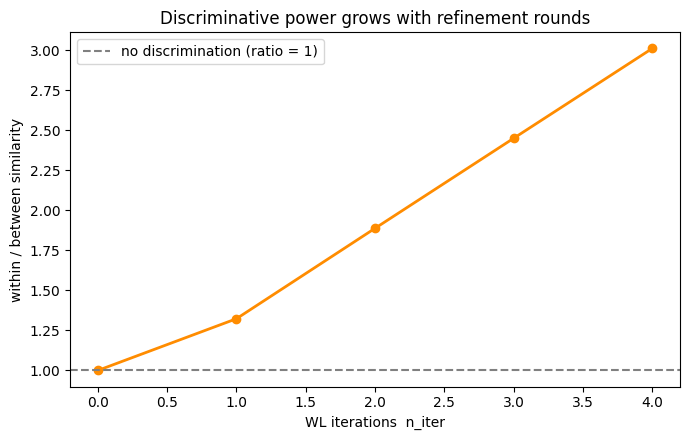

ratios: [1.0, 1.32, 1.89, 2.45, 3.01]


In [6]:
def gram(graphs, n_iter):
    m = len(graphs); G = torch.zeros(m, m)
    for i in range(m):
        for j in range(m):
            G[i, j] = wl_kernel(graphs[i], graphs[j], n_iter)
    return G

def normalize(K):                       # cosine-normalize so the diagonal is 1
    d = torch.sqrt(torch.diag(K))
    return K / (d[:, None] * d[None, :])

yt = torch.tensor(y)
within_mask  = (yt[:, None] == yt[None, :]) & ~torch.eye(n, dtype=bool)
between_mask =  yt[:, None] != yt[None, :]

iters = [0, 1, 2, 3, 4]
ratios = []
for it in iters:
    Kn = normalize(gram(graphs, it))
    ratios.append((Kn[within_mask].mean() / Kn[between_mask].mean()).item())

plt.figure(figsize=(7, 4.5))
plt.plot(iters, ratios, 'o-', color='darkorange', lw=2)
plt.axhline(1.0, color='gray', ls='--', label='no discrimination (ratio = 1)')
plt.xlabel('WL iterations  n_iter'); plt.ylabel('within / between similarity')
plt.title('Discriminative power grows with refinement rounds')
plt.legend(); plt.tight_layout(); plt.show()
print("ratios:", [round(r, 2) for r in ratios])

## 6. A limit WL cannot cross — the opening for a quantum kernel

WL has a famous blind spot: it cannot distinguish certain **non-isomorphic** graphs. The classic pair is a
single **6-cycle** vs. **two disjoint triangles** — both are 2-regular (every node has exactly two neighbours),
so every node refines to the *same* label forever and the WL histograms are **identical**, despite the graphs
being genuinely different.

This is precisely the gap a quantum kernel might exploit: Rydberg dynamics can be sensitive to global structure
(here, "one loop" vs. "two loops") that local label-refinement is blind to.

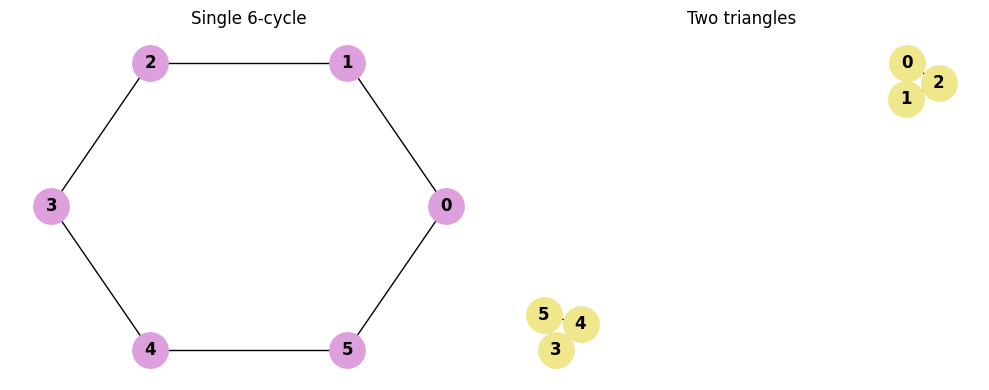

isomorphic (really the same graph)? False
identical WL histograms?            True  <- WL is fooled; a quantum kernel need not be


In [7]:
# 6-cycle
A_c6 = torch.zeros(6, 6)
for i in range(6):
    A_c6[i, (i + 1) % 6] = A_c6[(i + 1) % 6, i] = 1
# two disjoint triangles
A_2t = torch.zeros(6, 6)
for blk in [(0, 1, 2), (3, 4, 5)]:
    for a in blk:
        for b in blk:
            if a != b: A_2t[a, b] = 1

g_c6, g_2t = (A_c6, ["C"] * 6), (A_2t, ["C"] * 6)
G_c6, G_2t = nx.from_numpy_array(A_c6.numpy()), nx.from_numpy_array(A_2t.numpy())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
nx.draw(G_c6, nx.circular_layout(G_c6), with_labels=True, node_color='plum',
        node_size=650, font_weight='bold', ax=axes[0]); axes[0].set_title('Single 6-cycle')
nx.draw(G_2t, nx.spring_layout(G_2t, seed=3), with_labels=True, node_color='khaki',
        node_size=650, font_weight='bold', ax=axes[1]); axes[1].set_title('Two triangles')
plt.tight_layout(); plt.show()

print("isomorphic (really the same graph)?", nx.is_isomorphic(G_c6, G_2t))
print("identical WL histograms?           ", wl_histograms(*g_c6, 3) == wl_histograms(*g_2t, 3),
      " <- WL is fooled; a quantum kernel need not be")

---
# Lesson 05 — Generalization & Training Dynamics

Trainability is *the* problem in QML. This lesson makes the classical versions tangible, then connects them to
the quantum failure modes they mirror.

## 1. Overfitting vs. underfitting — the bias–variance U-curve

Fit polynomials of increasing degree to a small noisy sample. Training error keeps falling as the model gains
capacity, but **validation** error makes a U-turn: past a point the model fits the *noise*, not the signal.
The best model is the one that **generalizes**, not the one that fits the training data best.

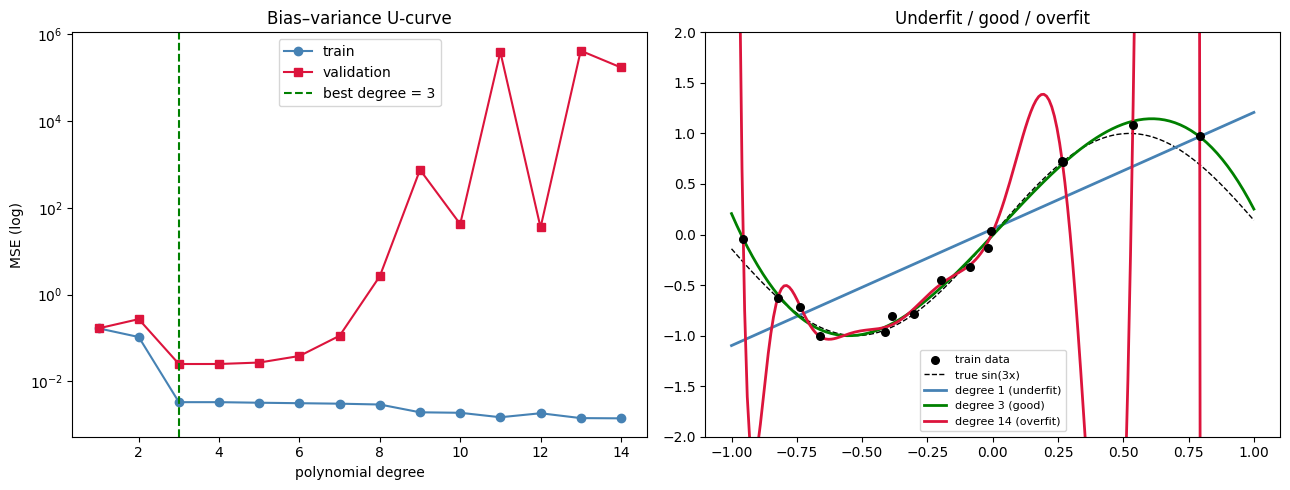

validation error bottoms out at degree 3


In [8]:
torch.manual_seed(0)
def make_data(m):
    x = torch.rand(m, 1) * 2 - 1
    return x, torch.sin(3 * x) + 0.1 * torch.randn(m, 1)

xtr, ytr = make_data(15)     # small -> easy to overfit
xva, yva = make_data(200)    # validation

def poly_features(x, degree):
    return torch.cat([x ** d for d in range(degree + 1)], dim=1)

degrees = list(range(1, 15))
train_mse, val_mse = [], []
for d in degrees:
    coef = torch.linalg.lstsq(poly_features(xtr, d), ytr).solution
    train_mse.append(((poly_features(xtr, d) @ coef - ytr) ** 2).mean().item())
    val_mse.append(((poly_features(xva, d) @ coef - yva) ** 2).mean().item())
best = degrees[int(np.argmin(val_mse))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(degrees, train_mse, 'o-', color='steelblue', label='train')
ax1.plot(degrees, val_mse, 's-', color='crimson', label='validation')
ax1.axvline(best, color='green', ls='--', label=f'best degree = {best}')
ax1.set_yscale('log'); ax1.set_xlabel('polynomial degree'); ax1.set_ylabel('MSE (log)')
ax1.set_title('Bias–variance U-curve'); ax1.legend()

xx = torch.linspace(-1, 1, 200).unsqueeze(1)
ax2.scatter(xtr, ytr, c='k', s=30, zorder=3, label='train data')
ax2.plot(xx, torch.sin(3 * xx), 'k--', lw=1, label='true sin(3x)')
for d, col, name in [(1, 'steelblue', 'underfit'), (best, 'green', 'good'), (14, 'crimson', 'overfit')]:
    coef = torch.linalg.lstsq(poly_features(xtr, d), ytr).solution
    ax2.plot(xx, poly_features(xx, d) @ coef, color=col, lw=2, label=f'degree {d} ({name})')
ax2.set_ylim(-2, 2); ax2.set_title('Underfit / good / overfit'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"validation error bottoms out at degree {best}")

## 2. Regularization tames variance

An L2 penalty (ridge / **weight decay**) shrinks coefficients and curbs overfitting — the same `λ` from
Lesson 03, now applied to a neural net via `weight_decay`. Too little lets the net chase noise; **too much**
flattens it into underfitting. As always: no free lunch, you tune it by cross-validation.

weight_decay=0.0   : val MSE 0.0322


weight_decay=0.001 : val MSE 0.0381


weight_decay=0.1   : val MSE 0.1288


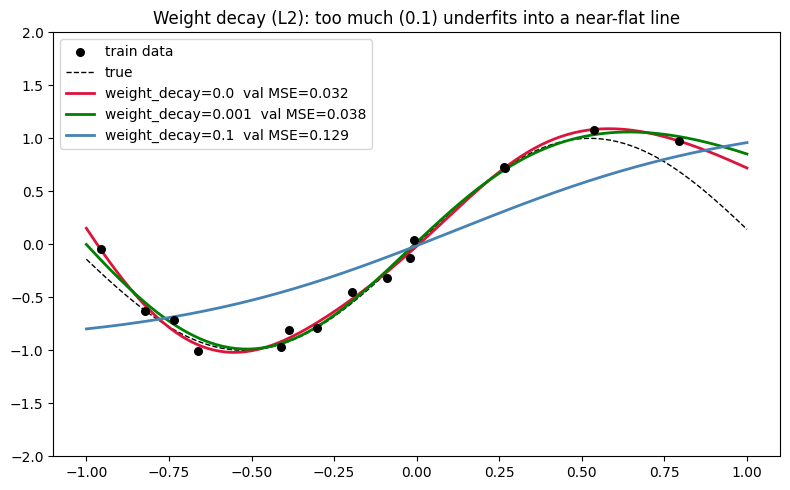

In [9]:
torch.manual_seed(0)
xtr = torch.rand(15, 1) * 2 - 1; ytr = torch.sin(3 * xtr) + 0.1 * torch.randn(15, 1)
xva = torch.rand(200, 1) * 2 - 1; yva = torch.sin(3 * xva) + 0.1 * torch.randn(200, 1)

def fit(weight_decay):
    torch.manual_seed(1)
    net = nn.Sequential(nn.Linear(1, 64), nn.Tanh(), nn.Linear(64, 1))
    opt = torch.optim.Adam(net.parameters(), lr=0.02, weight_decay=weight_decay)
    for _ in range(2000):
        opt.zero_grad(); ((net(xtr) - ytr) ** 2).mean().backward(); opt.step()
    return net

xx = torch.linspace(-1, 1, 200).unsqueeze(1)
plt.figure(figsize=(8, 5))
plt.scatter(xtr, ytr, c='k', s=30, zorder=3, label='train data')
plt.plot(xx, torch.sin(3 * xx), 'k--', lw=1, label='true')
for wd, col in zip([0.0, 1e-3, 1e-1], ['crimson', 'green', 'steelblue']):
    net = fit(wd)
    with torch.no_grad():
        val = ((net(xva) - yva) ** 2).mean().item()
        plt.plot(xx, net(xx), color=col, lw=2, label=f'weight_decay={wd}  val MSE={val:.3f}')
    print(f"weight_decay={wd:<6}: val MSE {val:.4f}")
plt.ylim(-2, 2); plt.title('Weight decay (L2): too much (0.1) underfits into a near-flat line')
plt.legend(); plt.tight_layout(); plt.show()

## 3. Cross-validation done right

**Never** select hyperparameters on the test set. k-fold CV reuses data honestly: split into `k` folds, train
on `k-1`, validate on the held-out fold, rotate, average. Pick the degree with the lowest CV error — a
principled model-selection rule that carries over *verbatim* to choosing quantum-kernel / circuit
hyperparameters.

degree  1: 5-fold CV MSE 0.1857
degree  3: 5-fold CV MSE 0.0130
degree  5: 5-fold CV MSE 0.0091
degree  7: 5-fold CV MSE 0.0097
degree  9: 5-fold CV MSE 0.0102
degree 11: 5-fold CV MSE 0.0342


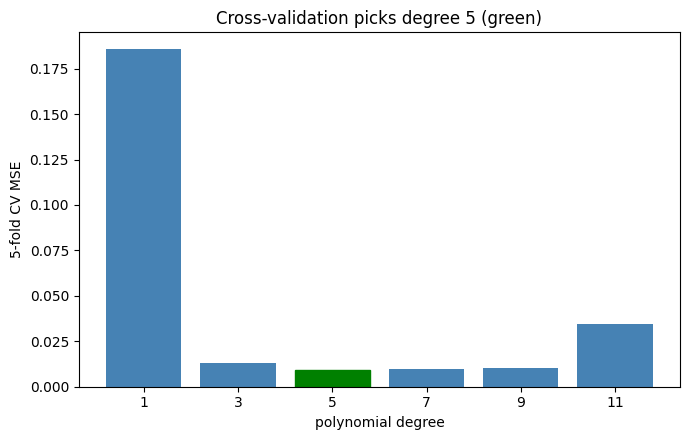

In [10]:
torch.manual_seed(0)
x = torch.rand(100, 1) * 2 - 1
yv = torch.sin(3 * x) + 0.1 * torch.randn(100, 1)

perm = torch.randperm(100)
folds = [perm[i::5] for i in range(5)]          # 5 disjoint folds, fixed across degrees for a fair comparison

def poly_features(x, d):
    return torch.cat([x ** i for i in range(d + 1)], 1)

degs = [1, 3, 5, 7, 9, 11]
cv = []
for d in degs:
    errs = []
    for f in range(5):
        val = folds[f]; tr = torch.cat([folds[i] for i in range(5) if i != f])
        coef = torch.linalg.lstsq(poly_features(x[tr], d), yv[tr]).solution
        errs.append(((poly_features(x[val], d) @ coef - yv[val]) ** 2).mean().item())
    cv.append(sum(errs) / 5)
    print(f"degree {d:2d}: 5-fold CV MSE {cv[-1]:.4f}")

best = int(np.argmin(cv))
plt.figure(figsize=(7, 4.5))
bars = plt.bar([str(d) for d in degs], cv, color='steelblue')
bars[best].set_color('green')
plt.xlabel('polynomial degree'); plt.ylabel('5-fold CV MSE')
plt.title(f'Cross-validation picks degree {degs[best]} (green)')
plt.tight_layout(); plt.show()

## 4. Barren plateaus: gradients that vanish with size

Here's the QML punchline made tangible. For a generic *expressive* parameterized model with random
initialization, the **variance of any single gradient component shrinks as the model grows**. When gradients
are exponentially small, training stalls on a flat "barren plateau".

We contrast two toy models, measuring `Var[∂out/∂θ₀]` over random parameters vs. width:

- **Expressive** (couples all parameters multiplicatively) → variance decays toward zero.
- **Structured / local** (output depends on θ₀ through a single rotation) → variance stays O(1).

In real variational circuits the decay is *exponential* in qubit count — which is why naive deep ansätze are
untrainable, and why **structure** (shallow circuits, symmetry, smart init) is essential.

width   2: expressive grad variance 4.36e-01
width   6: expressive grad variance 8.11e-02
width  12: expressive grad variance 4.04e-02
width  20: expressive grad variance 2.67e-02
width  40: expressive grad variance 1.25e-02
width  80: expressive grad variance 6.30e-03


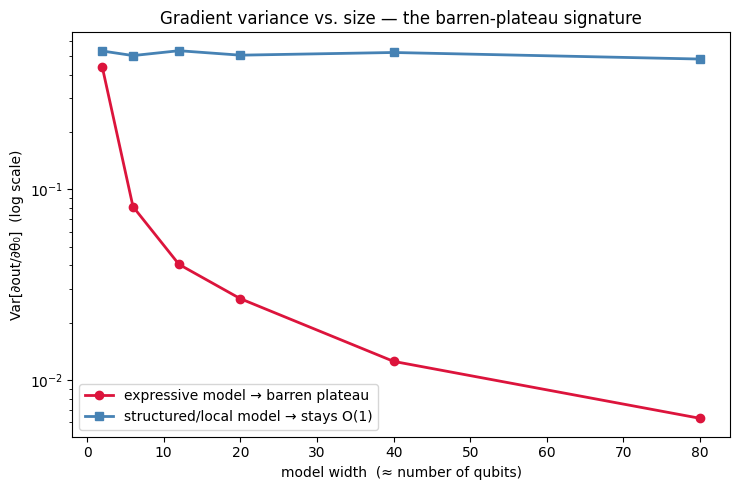

In [11]:
torch.manual_seed(0)
def grad_variance(width, expressive=True, n_samples=200):
    grads = []
    for _ in range(n_samples):
        theta = (torch.rand(width) * 2 * torch.pi).requires_grad_(True)
        if expressive:                                            # global, highly-coupled output
            out = torch.prod(torch.cos(theta)) + torch.mean(torch.sin(width ** 0.5 * theta))
        else:                                                     # local: output sees theta_0 only
            out = torch.sin(theta[0])
        out.backward()
        grads.append(theta.grad[0].item())
    return torch.tensor(grads).var().item()

widths = [2, 6, 12, 20, 40, 80]
v_exp  = [grad_variance(w, expressive=True)  for w in widths]
v_flat = [grad_variance(w, expressive=False) for w in widths]
for w, ve in zip(widths, v_exp):
    print(f"width {w:3d}: expressive grad variance {ve:.2e}")

plt.figure(figsize=(7.5, 5))
plt.semilogy(widths, v_exp,  'o-', color='crimson',   lw=2, label='expressive model → barren plateau')
plt.semilogy(widths, v_flat, 's-', color='steelblue', lw=2, label='structured/local model → stays O(1)')
plt.xlabel('model width  (≈ number of qubits)'); plt.ylabel('Var[∂out/∂θ₀]  (log scale)')
plt.title('Gradient variance vs. size — the barren-plateau signature')
plt.legend(); plt.tight_layout(); plt.show()

## 5. One trade-off, two faces

The punchline that ties Lesson 02 to Lesson 05: **barren plateaus** and **quantum-kernel concentration** are
not two problems but one. A 2025 result proves them *formally equivalent* (`arXiv:2501.07433`) — both are the
price of expressivity without structure. We show them collapsing side by side: gradient variance vanishing as
the model grows (left), and the RBF Gram matrix's off-diagonal *variance* vanishing as `σ` grows (right). In
both, the learning signal evaporates.

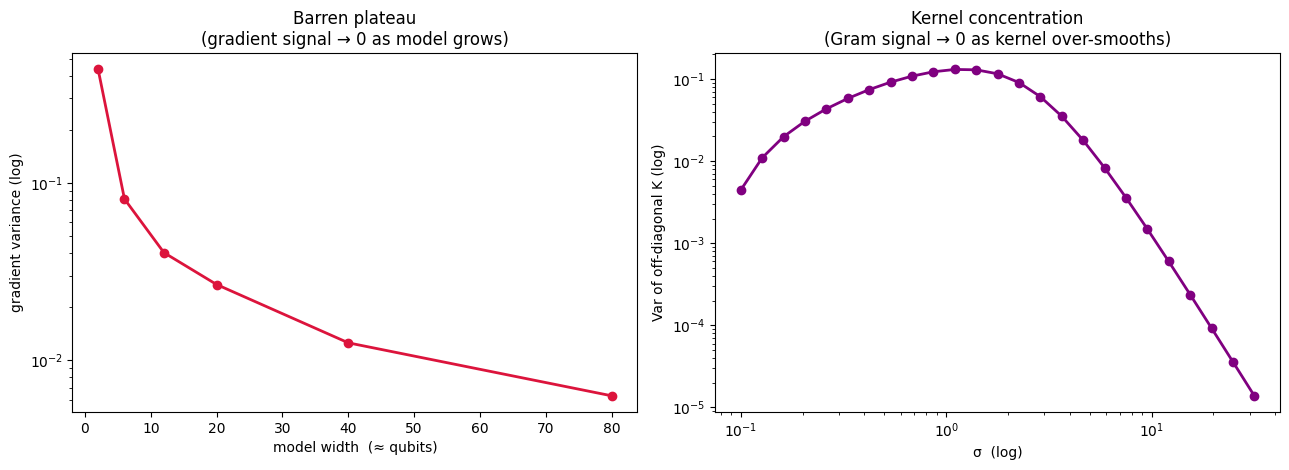

Two faces of the same expressivity-vs-learnability trade-off (arXiv:2501.07433).


In [12]:
def rbf(A, B, sigma):
    return torch.exp(-(torch.cdist(A, B) ** 2) / (2 * sigma ** 2))

X = torch.linspace(-3, 3, 40).unsqueeze(1)
off_mask = ~torch.eye(40, dtype=bool)
sigmas = torch.logspace(-1, 1.5, 25)
off_var = [rbf(X, X, s.item())[off_mask].var().item() for s in sigmas]   # spread of off-diagonal entries

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
ax1.semilogy(widths, v_exp, 'o-', color='crimson', lw=2)
ax1.set_xlabel('model width  (≈ qubits)'); ax1.set_ylabel('gradient variance (log)')
ax1.set_title('Barren plateau\n(gradient signal → 0 as model grows)')

ax2.loglog(sigmas, off_var, 'o-', color='purple', lw=2)
ax2.set_xlabel('σ  (log)'); ax2.set_ylabel('Var of off-diagonal K (log)')
ax2.set_title('Kernel concentration\n(Gram signal → 0 as kernel over-smooths)')
plt.tight_layout(); plt.show()
print("Two faces of the same expressivity-vs-learnability trade-off (arXiv:2501.07433).")

## The unifying picture

| Classical | Quantum analogue |
|-----------|------------------|
| Overfitting from too much capacity | Over-expressive ansatz / feature map |
| Vanishing/exploding gradients in deep nets | **Barren plateaus** (exp.-small gradients) |
| Kernel with near-identity Gram matrix is useless | **Exponential concentration** of quantum kernels |
| Regularization, architecture priors | Symmetry/equivariance, shallow & structured circuits |

The mitigations rhyme: in both worlds you fight *expressivity-without-learnability* by injecting **structure**.

**Where this connects:** Lesson 04's WL kernel is the classical graph baseline QEK must beat; its blind spot
(§6) is QEK's opportunity. Lesson 05's two collapses set up **Lesson 06** (concentration-free quantum kernels)
and **Lesson 10** (geometric/equivariant circuits that build in symmetry to dodge barren plateaus).

*References:* `arXiv:2107.03247` (QEK), `arXiv:2509.09421` (attributed-graph kernels via local detuning),
`arXiv:2501.07433` (concentration ↔ barren plateaus), `arXiv:2506.13865` (analog loss landscapes & phases of matter).